# Telco Customer Churn - 1. 전처리 (Preprocessing)
> IBM Telco Churn Dataset  
> 포함 내용: 패키지 설치 / 데이터 로드 / 정제 / EDA / 인코딩 / 피처 엔지니어링  
> 실행 후 마지막 셀에서 processed_data.csv 저장 -> 모델링 노트북에서 사용


## 0. 패키지 설치 (최초 1회만 실행)


In [1]:
# 최초 1회만 실행 (이미 설치되어 있으면 스킵)
# 터미널에서: pip install -r requirements.txt
# 또는 아래 셀 직접 실행
import subprocess
subprocess.run(['pip', 'install',
    'lightgbm', 'shap', 'imbalanced-learn',
    'optuna', 'optuna-integration[lightgbm]',
    '--quiet'], check=True)
print('설치 완료')


## 1. 라이브러리 임포트

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')

SEED = 42
np.random.seed(SEED)
print('라이브러리 임포트 완료')


## 2. 데이터 로드


In [5]:
# CSV 파일 경로를 지정하세요
# 예시 (Windows): FILE_PATH = r'C:\Users\이름\Downloads\Telco_customer_churn.csv'
# 예시 (Mac/Linux): FILE_PATH = '/Users/이름/Downloads/Telco_customer_churn.csv'
# 같은 폴더에 있을 때: FILE_PATH = 'Telco_customer_churn_-_Telco_Churn__2_.csv'

FILE_PATH = 'Telco_customer_churn_-_Telco_Churn__2_.csv'  # <- 경로 수정

import pandas as pd
df_raw = pd.read_csv(FILE_PATH)
print(f'데이터 로드 완료: {df_raw.shape[0]:,}행 x {df_raw.shape[1]}열')
df_raw.head(3)


## 3. 데이터 정제

In [6]:
df = df_raw.copy()

# ── 3-1. Total Charges: 공백 문자열 → float ──────────────────────────────
# 가입 기간 0개월인 신규 고객 행에 ' '(공백)이 들어있어 dtype이 object로 읽힘.
# errors='coerce' 로 공백 → NaN 변환 후 0 대체 (신규 = 청구 금액 없음)
n_blank = df['Total Charges'].eq(' ').sum()
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce').fillna(0)
print(f'Total Charges 변환 완료 — 공백 처리 건수: {n_blank}건')

# ── 3-2. 제거 컬럼 정의 ──────────────────────────────────────────────────
DROP_COLS = [
    # 식별자 & 상수 컬럼 (모델에 줄 정보가 없음)
    'CustomerID',    # 고객 고유 ID
    'Count',         # 전 행이 1 — 상수
    'Country',       # 전 행이 'United States' — 상수
    'State',         # 전 행이 'California' — 상수

    # 지역 정보 (카디널리티 과다 or 좌표 중복)
    'City',          # 1,129개 고유값 → 과적합 위험
    'Zip Code',      # 1,129개 고유값 → 과적합 위험
    'Lat Long',      # Latitude + Longitude 합본 문자열 — 중복
    'Latitude',      # 지리 좌표 — 모델링 불필요
    'Longitude',     # 지리 좌표 — 모델링 불필요

    # ⚠️  데이터 누수(Data Leakage) 변수
    # 누수 = 이탈 여부를 이미 알고 있는 변수를 학습에 사용하는 것.
    # 이런 변수를 포함하면 AUC 95%+ 가 나오지만 실전에서는 쓸 수 없음.
    'Churn Score',   # IBM이 이탈 기반으로 산출한 점수 → 직접 누수
    'CLTV',          # 이탈 위험 반영 IBM 산출값 → 간접 누수
    'Churn Reason',  # 이탈 후 사후 설문 → 이탈 전에는 존재 불가
    'Churn Label',   # Churn Value(0/1)의 문자열 버전 — 완전 중복
]

df.drop(columns=DROP_COLS, inplace=True)

print(f'정제 후 shape: {df.shape}')
null_check = df.isnull().sum()
null_check = null_check[null_check > 0]
print(f'결측치: {"없음 ✅" if null_check.empty else null_check}')

Total Charges 변환 완료 — 공백 처리 건수: 11건
정제 후 shape: (7043, 20)
결측치: 없음 ✅


## 4. EDA (탐색적 데이터 분석)

> 모델링 전에 데이터의 분포와 이탈과의 관계를 눈으로 확인하는 단계.  
> EDA에서 발견한 인사이트가 피처 엔지니어링 방향을 결정함.

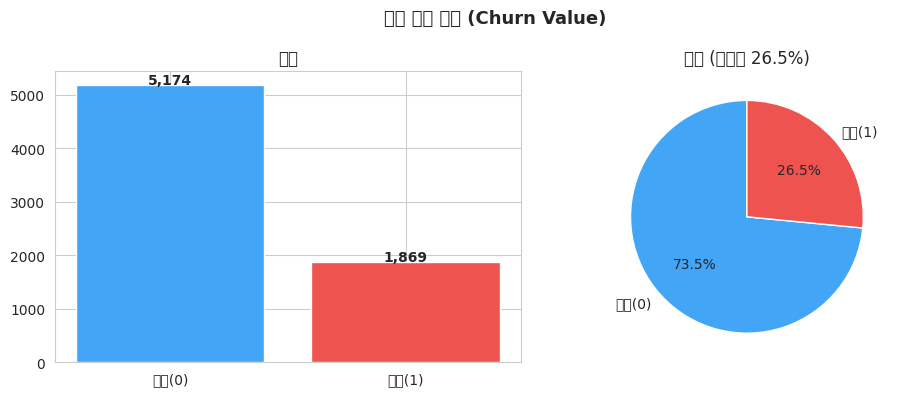

이탈: 1,869명 / 유지: 5,174명 / 이탈률: 26.5%


In [7]:
# ── 4-1. 타겟 분포 ────────────────────────────────────────────────────────
# 이탈률 확인 — 26% 수준이면 중간 정도의 불균형 (SMOTE 필요)
churn_counts = df['Churn Value'].value_counts()
churn_rate   = df['Churn Value'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('타겟 변수 분포 (Churn Value)', fontsize=13, fontweight='bold')

axes[0].bar(['유지(0)', '이탈(1)'], churn_counts.values,
            color=['#42A5F5', '#EF5350'], edgecolor='white')
axes[0].set_title('건수')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 30, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(churn_counts.values, labels=['유지(0)', '이탈(1)'],
            colors=['#42A5F5', '#EF5350'], autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white'})
axes[1].set_title(f'비율 (이탈률 {churn_rate:.1f}%)')

plt.tight_layout()
plt.show()
print(f'이탈: {churn_counts[1]:,}명 / 유지: {churn_counts[0]:,}명 / 이탈률: {churn_rate:.1f}%')

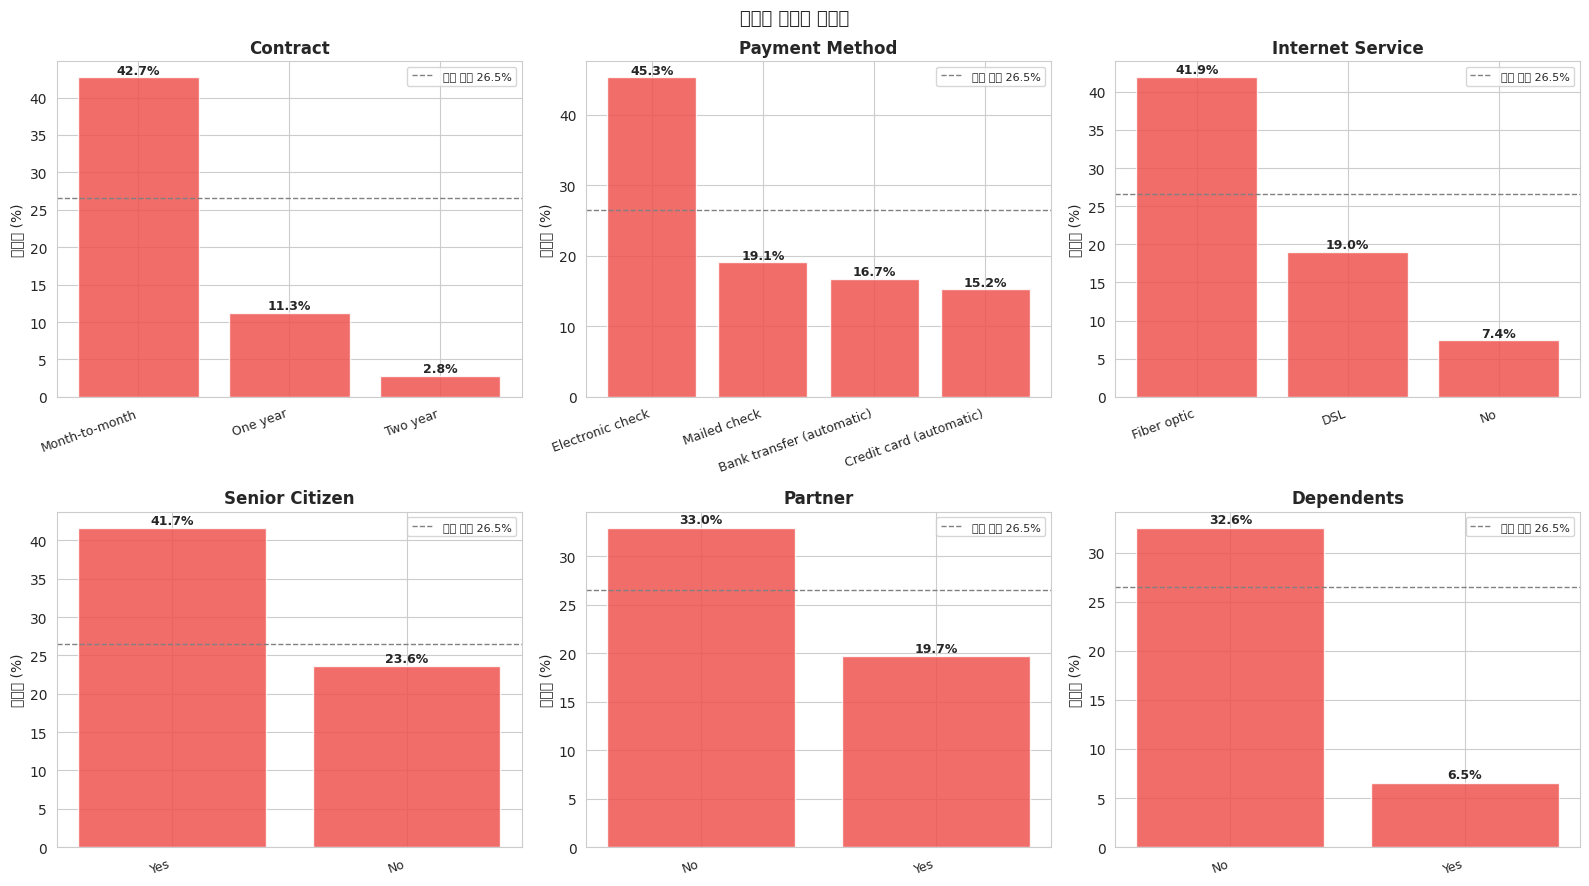

In [8]:
# ── 4-2. 주요 범주형 피처 vs 이탈률 ─────────────────────────────────────
# 이탈률이 높은 피처를 먼저 시각적으로 확인 → 피처 엔지니어링 힌트
cat_features = ['Contract', 'Payment Method', 'Internet Service',
                'Senior Citizen', 'Partner', 'Dependents']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('범주형 피처별 이탈률', fontsize=13, fontweight='bold')
axes = axes.flatten()

for ax, col in zip(axes, cat_features):
    churn_by_col = df.groupby(col)['Churn Value'].mean() * 100
    churn_by_col = churn_by_col.sort_values(ascending=False)
    bars = ax.bar(range(len(churn_by_col)), churn_by_col.values,
                  color='#EF5350', edgecolor='white', alpha=0.85)
    ax.set_xticks(range(len(churn_by_col)))
    ax.set_xticklabels(churn_by_col.index, rotation=20, ha='right', fontsize=9)
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('이탈률 (%)')
    ax.axhline(churn_rate, color='gray', linestyle='--', linewidth=1,
               label=f'전체 평균 {churn_rate:.1f}%')
    ax.legend(fontsize=8)
    for i, v in enumerate(churn_by_col.values):
        ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

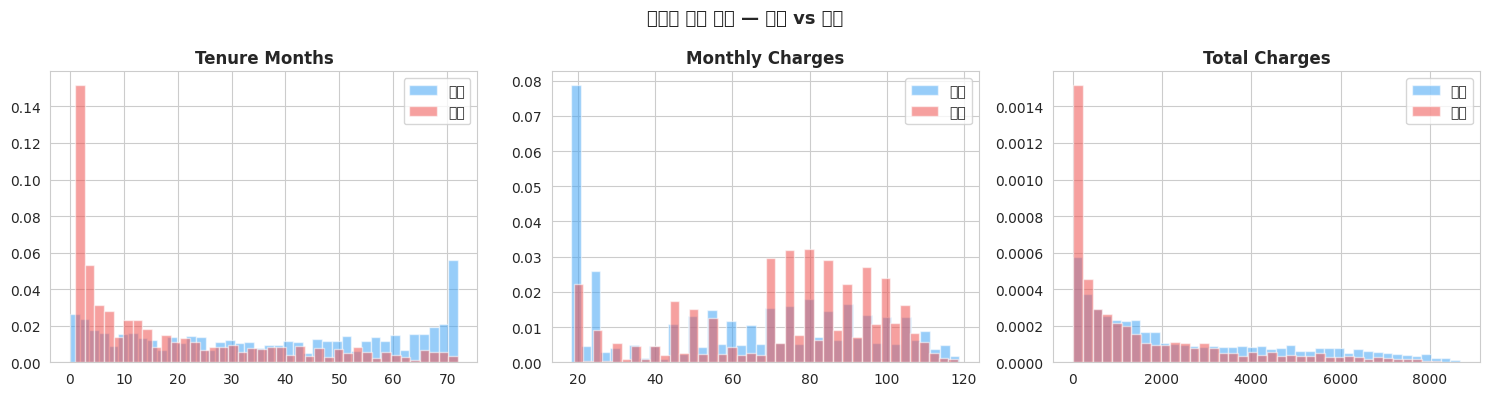

[EDA 인사이트]
  · Tenure Months — 이탈 고객 중앙값: 10개월 vs 유지 고객: 38개월
  · Monthly Charges — 이탈 고객 평균: $74.4 vs 유지 고객: $61.3


In [9]:
# ── 4-3. 수치형 피처 분포 (이탈 vs 유지) ────────────────────────────────
# KDE(커널 밀도 추정) 그래프로 이탈/유지 고객의 분포 형태 비교
num_features = ['Tenure Months', 'Monthly Charges', 'Total Charges']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('수치형 피처 분포 — 이탈 vs 유지', fontsize=13, fontweight='bold')

for ax, col in zip(axes, num_features):
    for label, color in [(0, '#42A5F5'), (1, '#EF5350')]:
        subset = df[df['Churn Value'] == label][col]
        ax.hist(subset, bins=40, alpha=0.55, color=color,
                label='유지' if label == 0 else '이탈', density=True)
    ax.set_title(col, fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.show()

# 인사이트 출력
print('[EDA 인사이트]')
print(f'  · Tenure Months — 이탈 고객 중앙값: {df[df["Churn Value"]==1]["Tenure Months"].median():.0f}개월'
      f' vs 유지 고객: {df[df["Churn Value"]==0]["Tenure Months"].median():.0f}개월')
print(f'  · Monthly Charges — 이탈 고객 평균: ${df[df["Churn Value"]==1]["Monthly Charges"].mean():.1f}'
      f' vs 유지 고객: ${df[df["Churn Value"]==0]["Monthly Charges"].mean():.1f}')

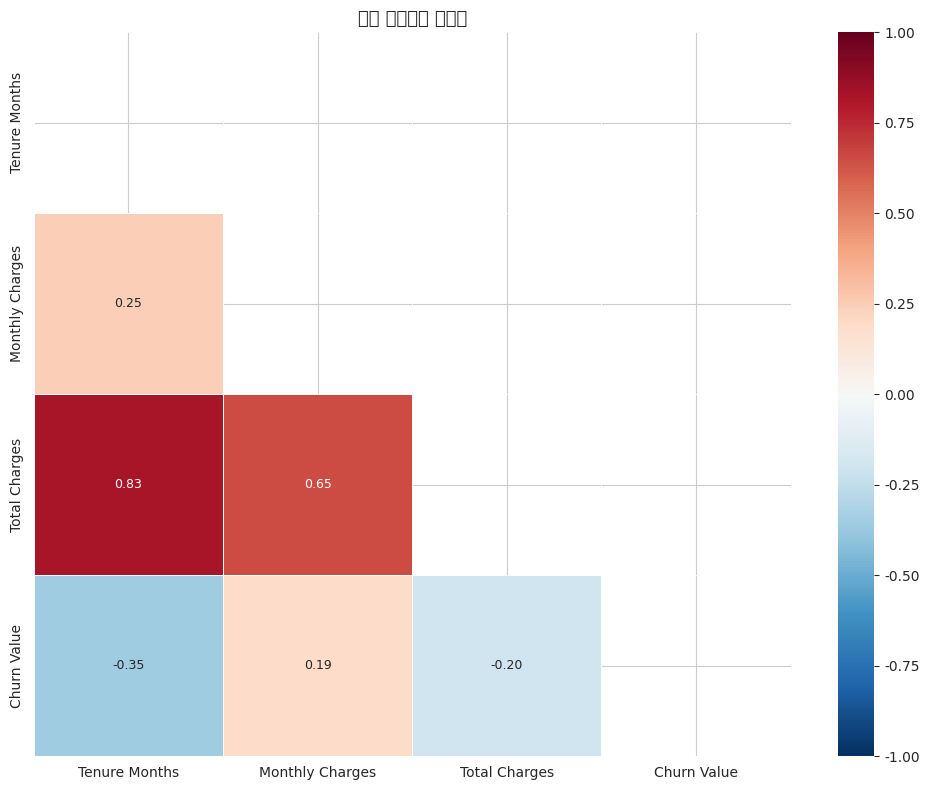


[Churn Value 상관계수 상위 피처]
  Tenure Months             0.352
  Total Charges             0.198
  Monthly Charges           0.193


In [10]:
# ── 4-4. 상관관계 히트맵 ──────────────────────────────────────────────────
# 수치형 컬럼만 선택해서 Churn Value와의 상관계수 확인
# 절대값이 높을수록 이탈 예측에 유용한 피처일 가능성이 높음
num_cols = df.select_dtypes(include='number').columns.tolist()
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # 상삼각 마스킹
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, annot_kws={'size': 9})
plt.title('피처 상관관계 히트맵', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Churn Value와 상관계수 순위 출력
churn_corr = corr_matrix['Churn Value'].drop('Churn Value').abs().sort_values(ascending=False)
print('\n[Churn Value 상관계수 상위 피처]')
for col, val in churn_corr.head(8).items():
    print(f'  {col:<25} {val:.3f}')

## 5. 인코딩

In [11]:
# ── 5-1. 이진형 변수 (Yes/No, Female/Male → 1/0) ─────────────────────────
binary_cols = ['Gender', 'Senior Citizen', 'Partner', 'Dependents',
               'Phone Service', 'Paperless Billing']
binary_map  = {'Yes': 1, 'No': 0, 'Female': 1, 'Male': 0}

for col in binary_cols:
    df[col] = df[col].map(binary_map)
    null_n  = df[col].isnull().sum()
    status  = '✅' if null_n == 0 else f'⚠️  NaN {null_n}개'
    print(f'  {col}: {status}')

# ── 5-2. 인터넷/전화 부가서비스 — 'No internet/phone service' → 'No' 통합 후 이진화
# 'No internet service'는 사실상 'No'와 동일한 의미이므로 통합
internet_sub_cols = ['Online Security', 'Online Backup', 'Device Protection',
                     'Tech Support', 'Streaming TV', 'Streaming Movies']
for col in internet_sub_cols:
    df[col] = df[col].replace('No internet service', 'No').map({'Yes': 1, 'No': 0})

df['Multiple Lines'] = (
    df['Multiple Lines'].replace('No phone service', 'No').map({'Yes': 1, 'No': 0})
)
print('\n인터넷/전화 부가서비스 인코딩 완료 ✅')

# ── 5-3. Contract — Ordinal Encoding ────────────────────────────────────
# 이탈률: Month-to-month(42.7%) > One year(11.3%) > Two year(2.8%)
# 기간이 길수록 이탈률이 낮으므로 순서 인코딩이 적합
contract_map = {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
df['Contract'] = df['Contract'].map(contract_map)
print('Contract Ordinal 인코딩 완료 ✅')

# ── 5-4. Payment Method & Internet Service — One-Hot Encoding ───────────
# 순서가 없는 명목형 변수이므로 One-Hot 사용 (drop_first=False: 모든 더미 유지)
df = pd.get_dummies(df, columns=['Payment Method', 'Internet Service'], drop_first=False)
bool_cols = df.select_dtypes(include='bool').columns.tolist()
df[bool_cols] = df[bool_cols].astype(int)   # bool → int (sklearn 호환)
print('One-Hot 인코딩 완료 ✅')
print(f'\n인코딩 후 shape: {df.shape}')

  Gender: ✅
  Senior Citizen: ✅
  Partner: ✅
  Dependents: ✅
  Phone Service: ✅
  Paperless Billing: ✅

인터넷/전화 부가서비스 인코딩 완료 ✅
Contract Ordinal 인코딩 완료 ✅
One-Hot 인코딩 완료 ✅

인코딩 후 shape: (7043, 25)


## 6. 피처 엔지니어링

> **v3 변경사항**  
> - 기존 6개 유지: `Avg_Monthly_Revenue`, `Num_Services`, `Num_Family`, `Charge_Per_Service`, `Senior_MtM`, `Is_New_High_Cost`  
> - **NEW 4개 추가**: `Charge_Delta`, `Value_Density`, `Fiber_Echeck`, `Tenure_x_Contract`


In [12]:
# ── 6-1. Avg_Monthly_Revenue — 월 평균 실제 지출액 ───────────────────────
df['Avg_Monthly_Revenue'] = np.where(
    df['Tenure Months'] > 0,
    df['Total Charges'] / df['Tenure Months'],
    df['Monthly Charges']
)
df.drop(columns=['Total Charges'], inplace=True)
print('Avg_Monthly_Revenue 생성 완료')

# ── 6-2. Num_Services — 가입 부가서비스 수 ───────────────────────────────
service_cols = ['Phone Service', 'Multiple Lines',
                'Online Security', 'Online Backup', 'Device Protection',
                'Tech Support', 'Streaming TV', 'Streaming Movies']
df['Num_Services'] = df[service_cols].sum(axis=1)
print(f'Num_Services 범위: {df["Num_Services"].min()} ~ {df["Num_Services"].max()}')

# ── 6-3. Num_Family — 가족 결합도 ───────────────────────────────────────
df['Num_Family'] = df['Partner'] + df['Dependents']
print(f'Num_Family 분포: {df["Num_Family"].value_counts().sort_index().to_dict()}')

# ── 6-4. Charge_Per_Service — 서비스당 단가 ──────────────────────────────
df['Charge_Per_Service'] = df['Monthly Charges'] / (df['Num_Services'] + 1)

# ── 6-5. Senior_MtM — 시니어 × 자유계약 위험 플래그 ─────────────────────
df['Senior_MtM'] = df['Senior Citizen'] * (df['Contract'] == 0).astype(int)

# ── 6-6. Is_New_High_Cost — 초기 고비용 이탈 위험 ───────────────────────
monthly_median = df['Monthly Charges'].median()
df['Is_New_High_Cost'] = (
    (df['Tenure Months'] <= 6) & (df['Monthly Charges'] > monthly_median)
).astype(int)
rate_nhc  = df[df['Is_New_High_Cost'] == 1]['Churn Value'].mean() * 100
rate_smtm = df[df['Senior_MtM'] == 1]['Churn Value'].mean() * 100
print(f'Is_New_High_Cost 이탈률: {rate_nhc:.1f}%')
print(f'Senior_MtM 이탈률:       {rate_smtm:.1f}%')

# ════════════════════════════════════════════════════════════════════════════
# ── [NEW v3] 피처 4개 추가 ──────────────────────────────────────────────────
# ════════════════════════════════════════════════════════════════════════════

# ── 6-7. Charge_Delta — 요금 이상 감지 ───────────────────────────────────
# 현재 월 요금 - 평균 월 지출
# 양수: 최근 요금이 평균보다 오름 → 요금 인상 불만 이탈 신호
# 음수: 프로모션/할인 수혜 → 유지 동기
df['Charge_Delta'] = df['Monthly Charges'] - df['Avg_Monthly_Revenue']
delta_churn = df.groupby(pd.cut(df['Charge_Delta'],
    bins=[-9999, -5, 5, 9999],
    labels=['요금 하락', '변동 없음', '요금 상승']
))['Churn Value'].mean() * 100
print('\n[NEW] Charge_Delta 구간별 이탈률:')
for k, v in delta_churn.items():
    print(f'  {k}: {v:.1f}%')

# ── 6-8. Value_Density — 서비스 가치 밀도 ────────────────────────────────
# 가입 서비스 수 / 월 요금 → 높을수록 가성비 좋음 → 이탈↓
df['Value_Density'] = df['Num_Services'] / (df['Monthly Charges'] + 1)
try:
    vd_churn = df.groupby(pd.qcut(df['Value_Density'], 3,
        labels=['낮음', '보통', '높음']))['Churn Value'].mean() * 100
    print('[NEW] Value_Density 구간별 이탈률:')
    for k, v in vd_churn.items():
        print(f'  {k}: {v:.1f}%')
except Exception:
    print(f'[NEW] Value_Density 평균: {df["Value_Density"].mean():.4f}')

# ── 6-9. Fiber_Echeck — 고위험 복합 플래그 ───────────────────────────────
# EDA 확인: Fiber optic + Electronic check = 이탈률 최고 위험 조합
df['Fiber_Echeck'] = (
    (df['Internet Service_Fiber optic'] == 1) &
    (df['Payment Method_Electronic check'] == 1)
).astype(int)
rate_fe = df[df['Fiber_Echeck'] == 1]['Churn Value'].mean() * 100
n_fe    = df['Fiber_Echeck'].sum()
print(f'[NEW] Fiber_Echeck 이탈률: {rate_fe:.1f}%  (해당 고객: {n_fe:,}명)')

# ── 6-10. Tenure_x_Contract — 계약 안정성 점수 ───────────────────────────
# Contract(0=월납, 1=1년, 2=2년) × Tenure Months
# 장기계약 + 오랜 고객 = 매우 안정 / 월납 + 신규 = 매우 불안정
df['Tenure_x_Contract'] = df['Tenure Months'] * df['Contract']
print(f'[NEW] Tenure_x_Contract 범위: {df["Tenure_x_Contract"].min()} ~ {df["Tenure_x_Contract"].max()}')

print(f'\n피처 엔지니어링 완료 ✅')
print(f'기존 6개 + NEW 4개 = 총 파생 피처 10개')
print(f'전체 컬럼 수: {df.shape[1]}')


Avg_Monthly_Revenue 생성 완료
Num_Services 범위: 0 ~ 8
Num_Family 분포: {0: 3339, 1: 2379, 2: 1325}
Is_New_High_Cost 이탈률: 73.3%
Senior_MtM 이탈률:       54.6%

[NEW] Charge_Delta 구간별 이탈률:
  요금 하락: 50.5%
  변동 없음: 24.9%
  요금 상승: 51.8%
[NEW] Value_Density 구간별 이탈률:
  낮음: 48.1%
  보통: 19.8%
  높음: 11.6%
[NEW] Fiber_Echeck 이탈률: 53.2%  (해당 고객: 1,595명)
[NEW] Tenure_x_Contract 범위: 0 ~ 144

피처 엔지니어링 완료 ✅
기존 6개 + NEW 4개 = 총 파생 피처 10개
전체 컬럼 수: 34


## 7. 피처 / 타겟 분리 & 최종 검증

In [13]:
TARGET      = 'Churn Value'
feature_cols = [c for c in df.columns if c != TARGET]

X = df[feature_cols].copy()
y = df[TARGET].copy()

# ── 결측치 확인 ───────────────────────────────────────────────────────────
null_check = X.isnull().sum()
null_problem = null_check[null_check > 0]
print('결측치:', '없음 ✅' if null_problem.empty else f'\n{null_problem}')

# ── dtype 확인 (모든 피처가 숫자여야 LightGBM 학습 가능) ──────────────────
non_numeric = X.select_dtypes(exclude='number').columns.tolist()
print('비숫자 컬럼:', '없음 ✅' if not non_numeric else non_numeric)

print(f'\n최종 피처셋: {X.shape[0]:,}샘플 × {X.shape[1]}개 피처')
print(f'타겟 분포: 유지 {(y==0).sum():,}명({(y==0).mean()*100:.1f}%) / '
      f'이탈 {(y==1).sum():,}명({(y==1).mean()*100:.1f}%)')

print('\n[피처 목록]')
for i, col in enumerate(feature_cols, 1):
    print(f'  {i:2d}. {col}')

결측치: 없음 ✅
비숫자 컬럼: 없음 ✅

최종 피처셋: 7,043샘플 × 33개 피처
타겟 분포: 유지 5,174명(73.5%) / 이탈 1,869명(26.5%)

[피처 목록]
   1. Gender
   2. Senior Citizen
   3. Partner
   4. Dependents
   5. Tenure Months
   6. Phone Service
   7. Multiple Lines
   8. Online Security
   9. Online Backup
  10. Device Protection
  11. Tech Support
  12. Streaming TV
  13. Streaming Movies
  14. Contract
  15. Paperless Billing
  16. Monthly Charges
  17. Payment Method_Bank transfer (automatic)
  18. Payment Method_Credit card (automatic)
  19. Payment Method_Electronic check
  20. Payment Method_Mailed check
  21. Internet Service_DSL
  22. Internet Service_Fiber optic
  23. Internet Service_No
  24. Avg_Monthly_Revenue
  25. Num_Services
  26. Num_Family
  27. Charge_Per_Service
  28. Senior_MtM
  29. Is_New_High_Cost
  30. Charge_Delta
  31. Value_Density
  32. Fiber_Echeck
  33. Tenure_x_Contract


## 8. 전처리 결과 저장

> 아래 셀 실행 시 `processed_data.csv` 파일이 생성됩니다.  
> 이 파일을 모델링 노트북(`2_Modeling.ipynb`)과 같은 폴더에 놓고 실행하세요.


In [ ]:
# 전처리 완료된 데이터 저장
SAVE_PATH = 'processed_data.csv'
df.to_csv(SAVE_PATH, index=False)

print(f'저장 완료: {SAVE_PATH}')
print(f'shape: {df.shape}')
print(f'컬럼: {df.columns.tolist()}')
